# 9. Decision-Rule Ablation

Notebook 9 is the final paper-facing analysis notebook. It asks whether the complete decision-support system (DSS) changes the recommendation relative to simpler decision rules such as replay-only, replay-plus-guardrails, OPE-only, and Season-3-replay-only screens.

The point is not to rerun the whole empirical study. The point is to isolate the contribution of the integrated decision layer. A rule can identify the same attractive policy while still making the wrong operational recommendation if it converts offline evidence directly into launch. This notebook therefore compares both selected policies and launch actions.


## What This Notebook Creates

Inputs from earlier notebooks:

- `metadata/marketplace_scorecard.csv`
- `metadata/reserve_policy_guardrails.csv`
- `metadata/season2_vs_season3_policy_transfer.csv`
- `metadata/theory_guided_sensitivity_verdict.csv`
- `metadata/launch_readiness_checklist.csv`

Generated analysis artifacts:

- `metadata/decision_rule_policy_evidence.csv`
- `metadata/decision_rule_ablation_summary.csv`
- `metadata/decision_rule_gate_matrix.csv`
- `metadata/decision_rule_bootstrap_selection.csv`

Generated figures:

- `artifacts/figures/14_decision_rule_gate_matrix.png`
- `artifacts/figures/14_decision_rule_unresolved_gates.png`
- `artifacts/figures/14_decision_rule_bootstrap_selection.png`


## Reproducibility Setup

The ablation is deterministic given the paper artifacts produced earlier. It does not read raw iPinYou data, rebuild panels, or refit nuisance models. If a required input is missing, rerun the earlier notebook that creates it before executing this notebook.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing src/ and pyproject.toml")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"Repository root: {REPO_ROOT}")


Repository root: /home/apex/Documents/ranking_sys/notebooks/writing/ads_marketplace_auction_experimentation/marketplace-policies-code


In [2]:
from IPython.display import Image, display

from checks import ArtifactRepository
from config import ProjectPaths, RawPipelineConfig
from data_access import Workspace
from decision_engine import DecisionEngine
from figures import FigureRenderer
from policy_catalog import ReservePolicyCatalog
from progress import ProgressLogger


In [3]:
SOURCE_ROOT = REPO_ROOT / "artifacts" / "workspace"
OUTPUT_ROOT = REPO_ROOT / "artifacts"
RUN_DECISION_ABLATION = True
RENDER_FIGURES = True

paths = ProjectPaths.from_cli(SOURCE_ROOT, OUTPUT_ROOT)
paths.ensure_output_dirs()
repository = ArtifactRepository(paths)
repository.require_layout()
workspace = Workspace(paths.source_root)
progress = ProgressLogger(enabled=True)
config = RawPipelineConfig(
    data_root=REPO_ROOT / "data",
    workspace_root=SOURCE_ROOT,
    full_run=True,
    clean_workspace=False,
)

required = [
    paths.metadata_dir / "reserve_policy_price_landscape.csv",
    paths.metadata_dir / "reserve_policy_registry.csv",
    paths.metadata_dir / "marketplace_scorecard.csv",
    paths.metadata_dir / "reserve_policy_guardrails.csv",
    paths.metadata_dir / "season2_vs_season3_policy_transfer.csv",
    paths.metadata_dir / "launch_readiness_checklist.csv",
]
missing = [path.relative_to(REPO_ROOT) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Run notebooks 3, 4, 7, and 8 before decision-rule ablation. "
        f"Missing: {missing}"
    )

print("Required ablation inputs are present.")


Required ablation inputs are present.


## Frozen Policy Catalog

The ablation uses the same policy catalog and the same q25/q50/q75 floor thresholds used throughout the paper. This matters because simplified rules should be compared on the same policy universe as the full DSS, not on a separately tuned set of candidates.


In [4]:
price_landscape = repository.read_csv("reserve_policy_price_landscape.csv")
price_values = price_landscape.set_index("stat")["value"].to_dict()
price_quantiles = {
    "q25": float(price_values["positive_floor_q25"]),
    "q50": float(price_values["positive_floor_q50"]),
    "q75": float(price_values["positive_floor_q75"]),
}
catalog = ReservePolicyCatalog(price_quantiles)

catalog.registry().head()


,policy_id,policy_family,description,floor_rule,supported_by_replay_contract,policy_number,policy_label
0,logged_floor_status_quo,baseline,Logged floor exactly as observed.,logged,True,P0,Logged Status Quo
1,uniform_raise_05pct,uniform_percent,Raise every logged floor by 5 percent.,logged * 1.05,True,P1,Uniform +5%
2,uniform_raise_10pct,uniform_percent,Raise every logged floor by 10 percent.,logged * 1.10,True,P2,Uniform +10%
3,uniform_raise_15pct,uniform_percent,Raise every logged floor by 15 percent.,logged * 1.15,True,P3,Uniform +15%
4,uniform_raise_20pct,uniform_percent,Raise every logged floor by 20 percent.,logged * 1.20,True,P4,Uniform +20%


## Build Decision-Rule Ablation Artifacts

`DecisionEngine.build_final_decision_and_ablation()` refreshes the final recommendation and builds the ablation tables. Each simplified rule is allowed to use only a subset of the evidence:

- replay-only rules select by Season 2 replay lift;
- replay-plus-guardrails rules additionally require the policy to pass the replay guardrails;
- OPE rules select by the cross-fitted doubly robust mean or lower-tail lift;
- Season-3-replay-only rules select by out-of-time Season 3 replay lift;
- the full DSS selects by the weighted evidence score and returns an online-validation recommendation rather than a direct launch recommendation.

The important comparison is therefore two-dimensional: which policy is selected and what action the rule recommends.


In [5]:
if RUN_DECISION_ABLATION:
    DecisionEngine(workspace, config, catalog, progress=progress).build_final_decision_and_ablation()

policy_evidence = repository.read_csv("decision_rule_policy_evidence.csv")
ablation = repository.read_csv("decision_rule_ablation_summary.csv")
gate_matrix = repository.read_csv("decision_rule_gate_matrix.csv")
selection = repository.read_csv("decision_rule_bootstrap_selection.csv")

print(f"Policy evidence rows: {len(policy_evidence):,}")
print(f"Decision rules compared: {len(ablation):,}")
ablation[[
    "rule_label",
    "selection_basis",
    "selected_policy_number",
    "selected_policy_label",
    "recommended_action_under_rule",
    "direct_launch_overclaim",
    "unresolved_launch_gate_count",
]]


[     0.2s] Starting: final decision and ablation artifacts
[     0.2s] Finished: final decision and ablation artifacts; wrote 6 rule comparisons
Policy evidence rows: 16
Decision rules compared: 6


,rule_label,selection_basis,selected_policy_number,selected_policy_label,recommended_action_under_rule,direct_launch_overclaim,unresolved_launch_gate_count
0,Replay-only,Max season2_replay_lift,P18,Q75 Margin-Gated Floor,direct_launch,True,6
1,Replay + guardrails,Max season2_replay_lift,P18,Q75 Margin-Gated Floor,direct_launch,True,5
2,OPE mean-only,Max crossfit_dr_pct_lift_vs_baseline,P18,Q75 Margin-Gated Floor,direct_launch,True,6
3,OPE lower-tail-only,Max crossfit_dr_pct_lift_p10,P18,Q75 Margin-Gated Floor,direct_launch,True,5
4,Season-3 replay-only,Max season3_pct_yield_lift,P18,Q75 Margin-Gated Floor,direct_launch,True,5
5,Full DSS,Max weighted_evidence_score,P18,Q75 Margin-Gated Floor,validate_online,False,0


## Ablation Summary Table

The table below is the compact result. A simplified rule may select the same priority policy as the DSS, but still overclaim if it recommends direct launch without accounting for missing propensities, online marketplace response, or interference pathways. This is the core empirical reason for treating the integration layer as part of the method rather than a cosmetic checklist.


In [6]:
summary = ablation[[
    "rule_label",
    "selected_policy_number",
    "selected_policy_label",
    "selected_score_column",
    "selected_score",
    "recommended_action_under_rule",
    "direct_launch_overclaim",
    "unresolved_launch_gate_count",
    "season2_replay_lift",
    "season3_pct_yield_lift",
    "basic_guardrails_pass",
    "support_validation_ready",
]].copy()

def format_score(row):
    score_col = str(row["selected_score_column"])
    score = row["selected_score"]
    if score != score:
        return ""
    if "lift" in score_col or "pct" in score_col:
        return f"{100 * score:.1f}%"
    return f"{score:.3f}"

summary["selected_score_display"] = summary.apply(format_score, axis=1)
for col in ["season2_replay_lift", "season3_pct_yield_lift"]:
    summary[col] = summary[col].map(lambda x: "" if x != x else f"{100 * x:.1f}%")

summary.drop(columns=["selected_score"]).rename(columns={"selected_score_display": "selected_score"})


,rule_label,selected_policy_number,selected_policy_label,selected_score_column,recommended_action_under_rule,direct_launch_overclaim,unresolved_launch_gate_count,season2_replay_lift,season3_pct_yield_lift,basic_guardrails_pass,support_validation_ready,selected_score
0,Replay-only,P18,Q75 Margin-Gated Floor,season2_replay_lift,direct_launch,True,6,47.7%,43.9%,True,True,47.7%
1,Replay + guardrails,P18,Q75 Margin-Gated Floor,season2_replay_lift,direct_launch,True,5,47.7%,43.9%,True,True,47.7%
2,OPE mean-only,P18,Q75 Margin-Gated Floor,crossfit_dr_pct_lift_vs_baseline,direct_launch,True,6,47.7%,43.9%,True,True,48.7%
3,OPE lower-tail-only,P18,Q75 Margin-Gated Floor,crossfit_dr_pct_lift_p10,direct_launch,True,5,47.7%,43.9%,True,True,45.8%
4,Season-3 replay-only,P18,Q75 Margin-Gated Floor,season3_pct_yield_lift,direct_launch,True,5,47.7%,43.9%,True,True,43.9%
5,Full DSS,P18,Q75 Margin-Gated Floor,weighted_evidence_score,validate_online,False,0,47.7%,43.9%,True,True,4.305


## Figure: Which Evidence Each Rule Uses

The gate matrix shows the information set available to each rule. The simplified rules intentionally omit one or more evidence classes. The full DSS uses all evidence classes: replay, replay guardrails, OPE, support diagnostics, Season 3 validation, response sensitivity, and the final interference/propensity launch blocker.


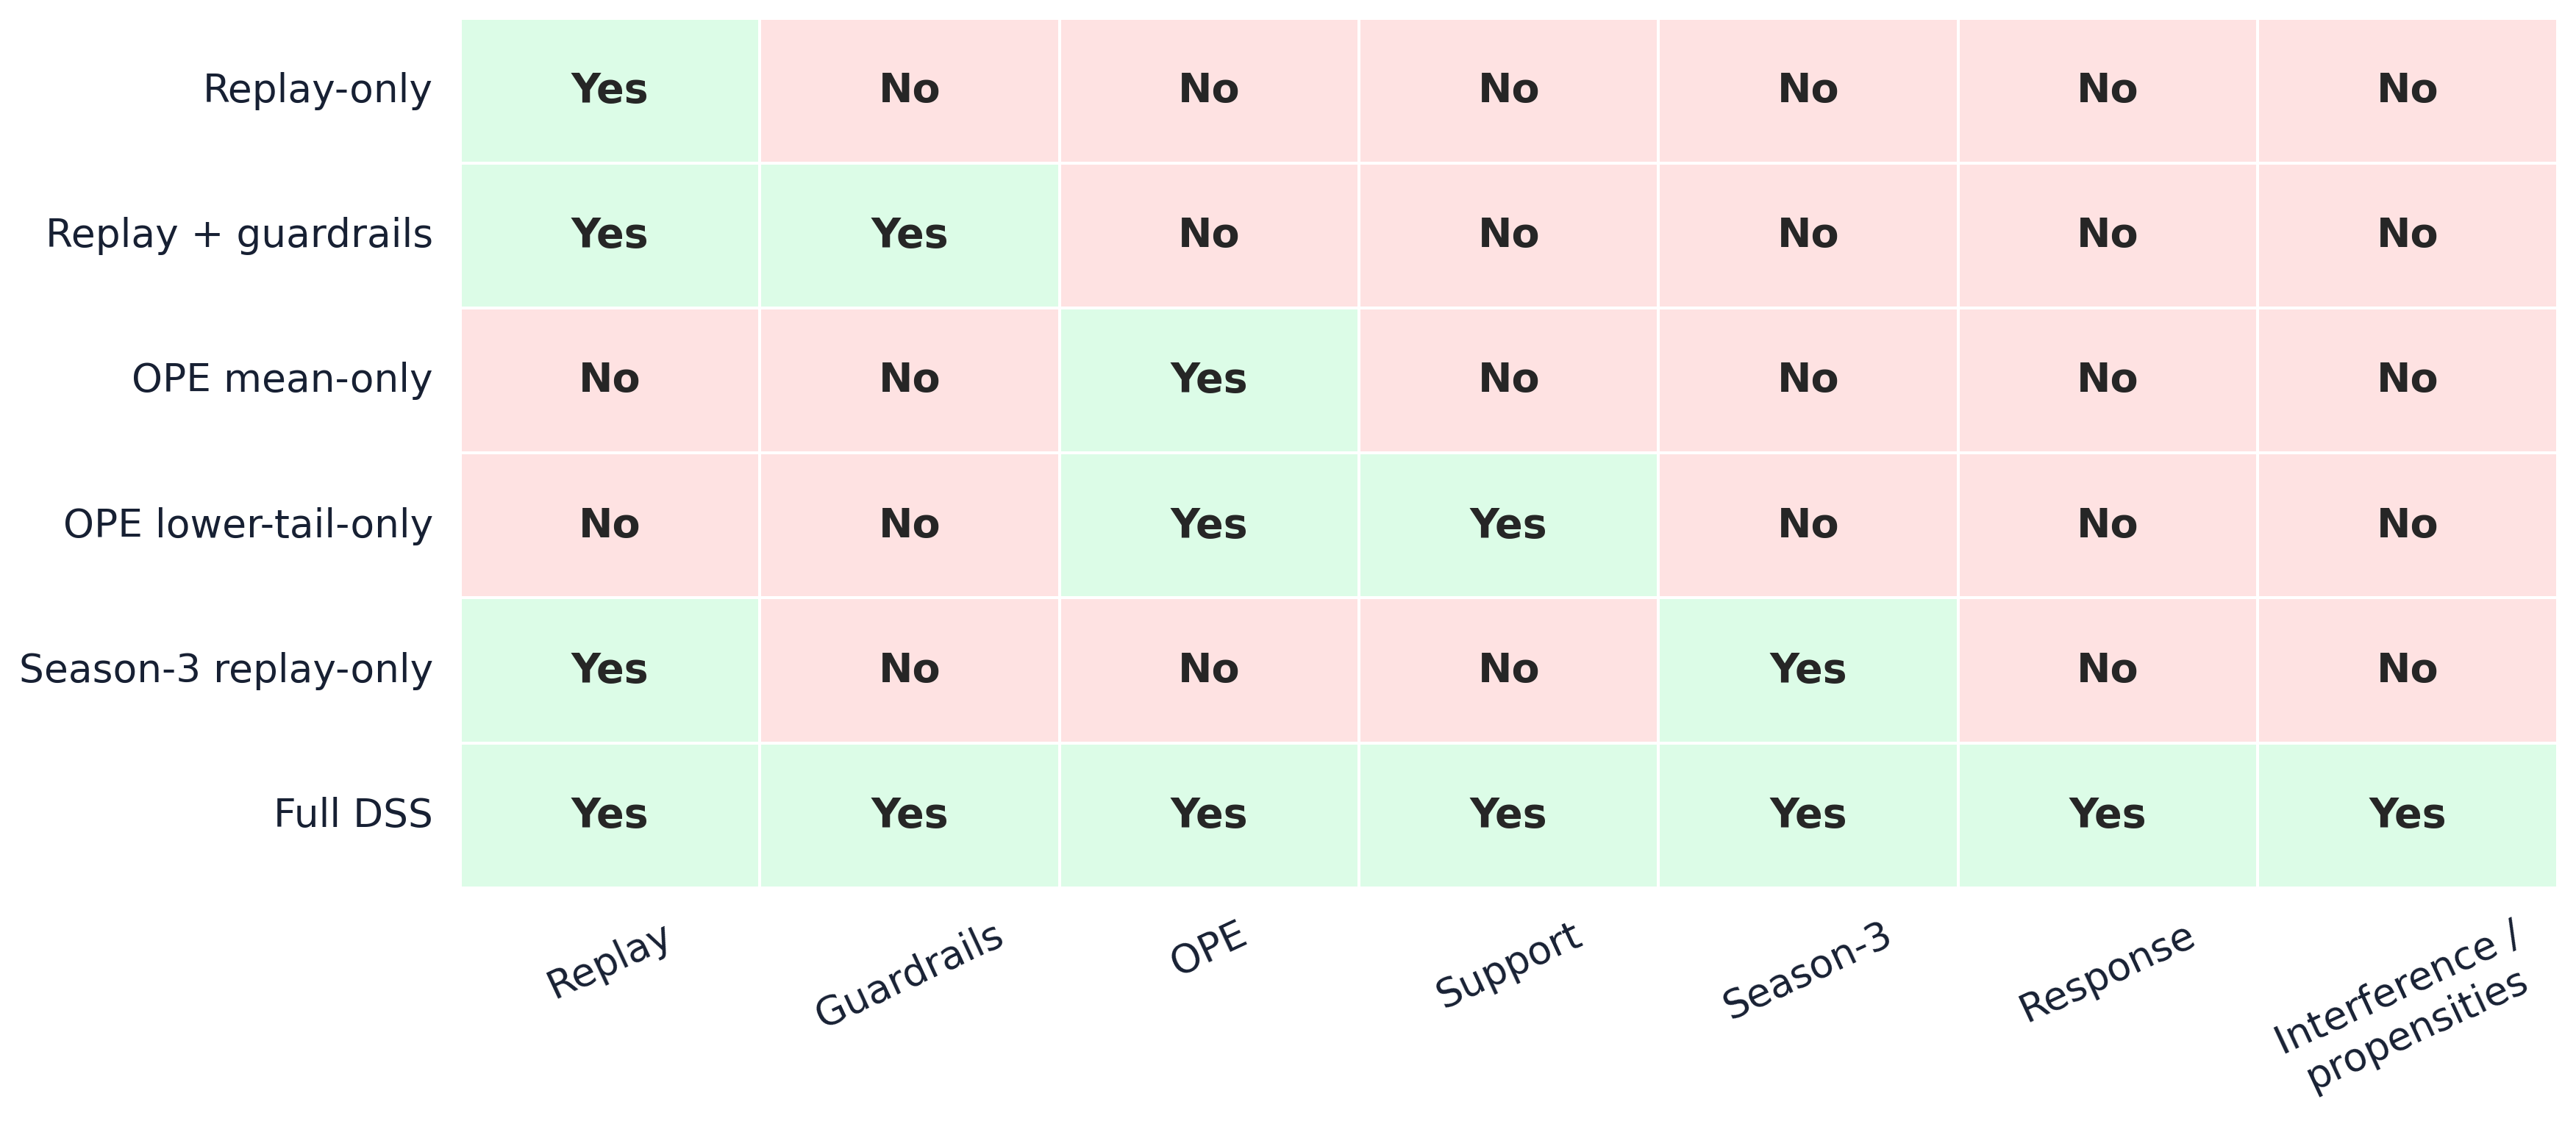

artifacts/figures/14_decision_rule_gate_matrix.png


In [7]:
renderer = FigureRenderer(repository, paths.figure_dir)
if RENDER_FIGURES:
    gate_path = renderer.plot_decision_rule_gate_matrix()
else:
    gate_path = paths.figure_dir / "14_decision_rule_gate_matrix.png"

display(Image(filename=str(gate_path)))
print(gate_path.relative_to(REPO_ROOT))


## Figure: Unresolved Launch Gates

This panel converts the information-set comparison into a decision implication. Rules that recommend direct launch while omitting unresolved evidence classes carry launch debt. The full DSS does not claim zero risk; instead, it routes the priority policy into online validation, which is why its unresolved direct-launch gate count is zero under the rule action.


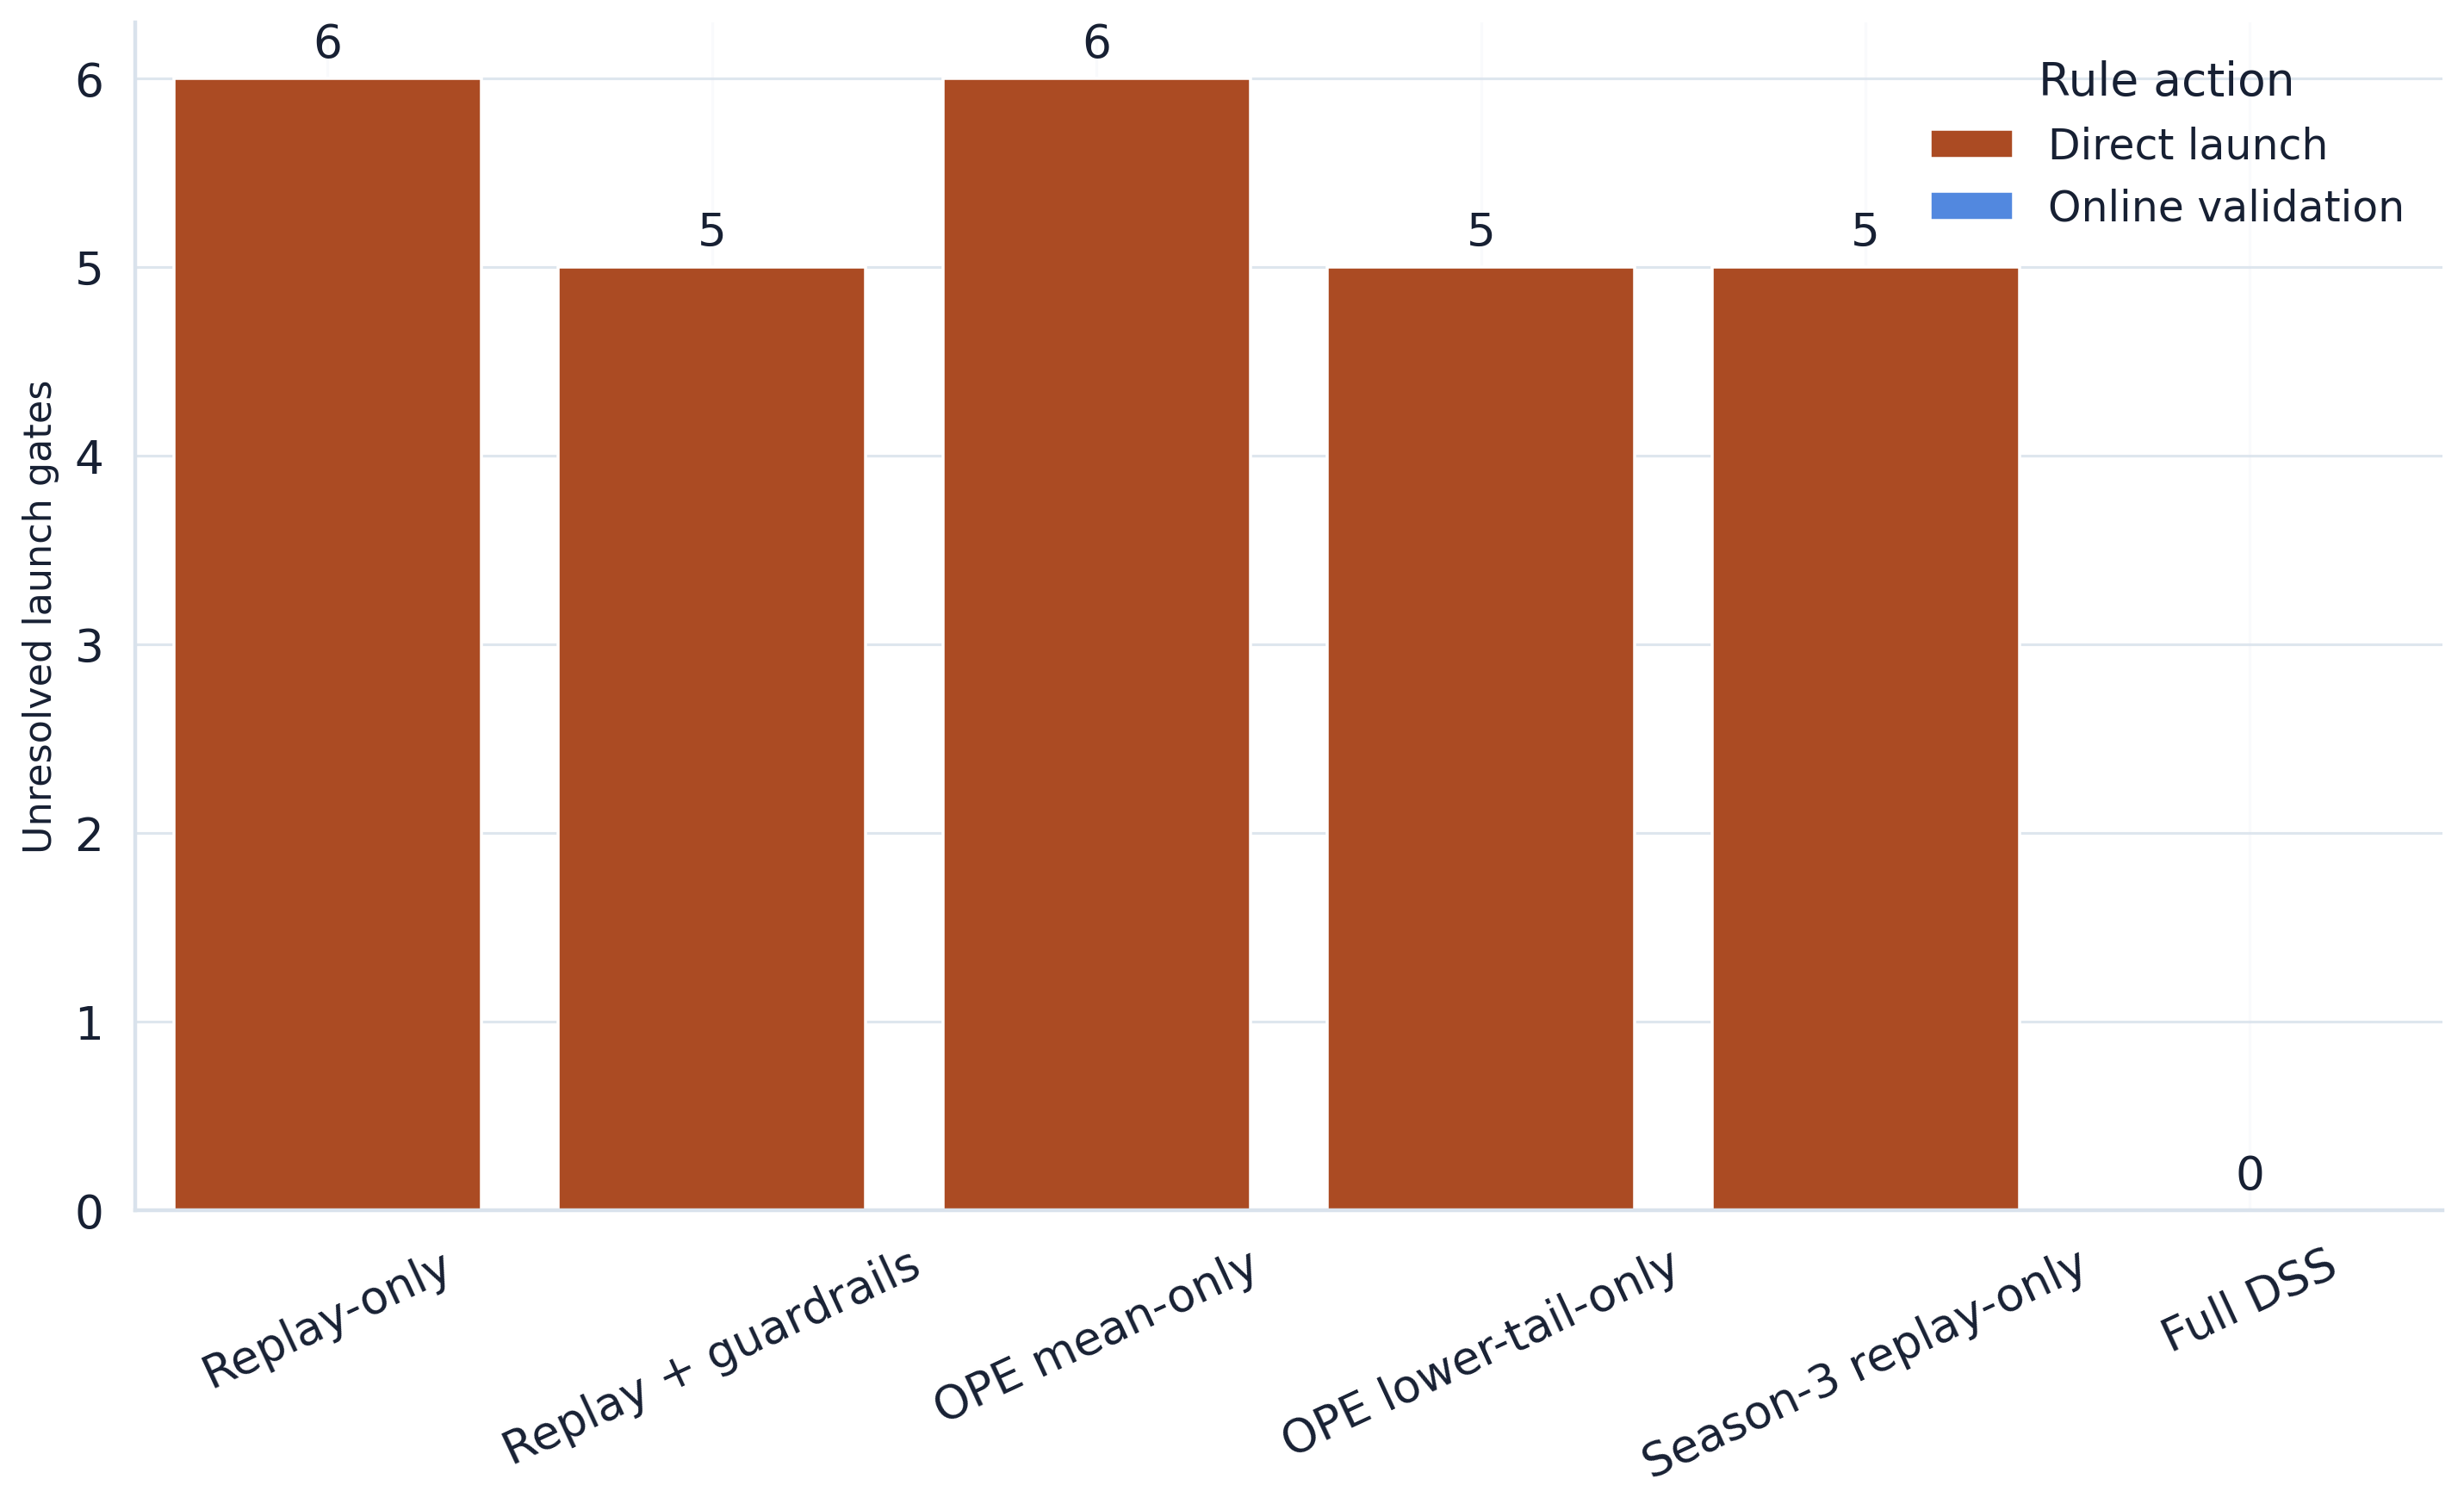

artifacts/figures/14_decision_rule_unresolved_gates.png


In [8]:
if RENDER_FIGURES:
    unresolved_path = renderer.plot_decision_rule_unresolved_gates()
else:
    unresolved_path = paths.figure_dir / "14_decision_rule_unresolved_gates.png"

display(Image(filename=str(unresolved_path)))
print(unresolved_path.relative_to(REPO_ROOT))


## Figure: Selection Concentration

The selection-concentration figure reports the top policies under each rule's scoring criterion. It is a deterministic score-margin diagnostic, not a new model fit. When a simplified rule and the full DSS select the same leading policy, the remaining difference is the action: direct launch versus staged validation. When a simplified rule selects a different policy, the ablation also exposes how evidence choice changes the policy ranking itself.


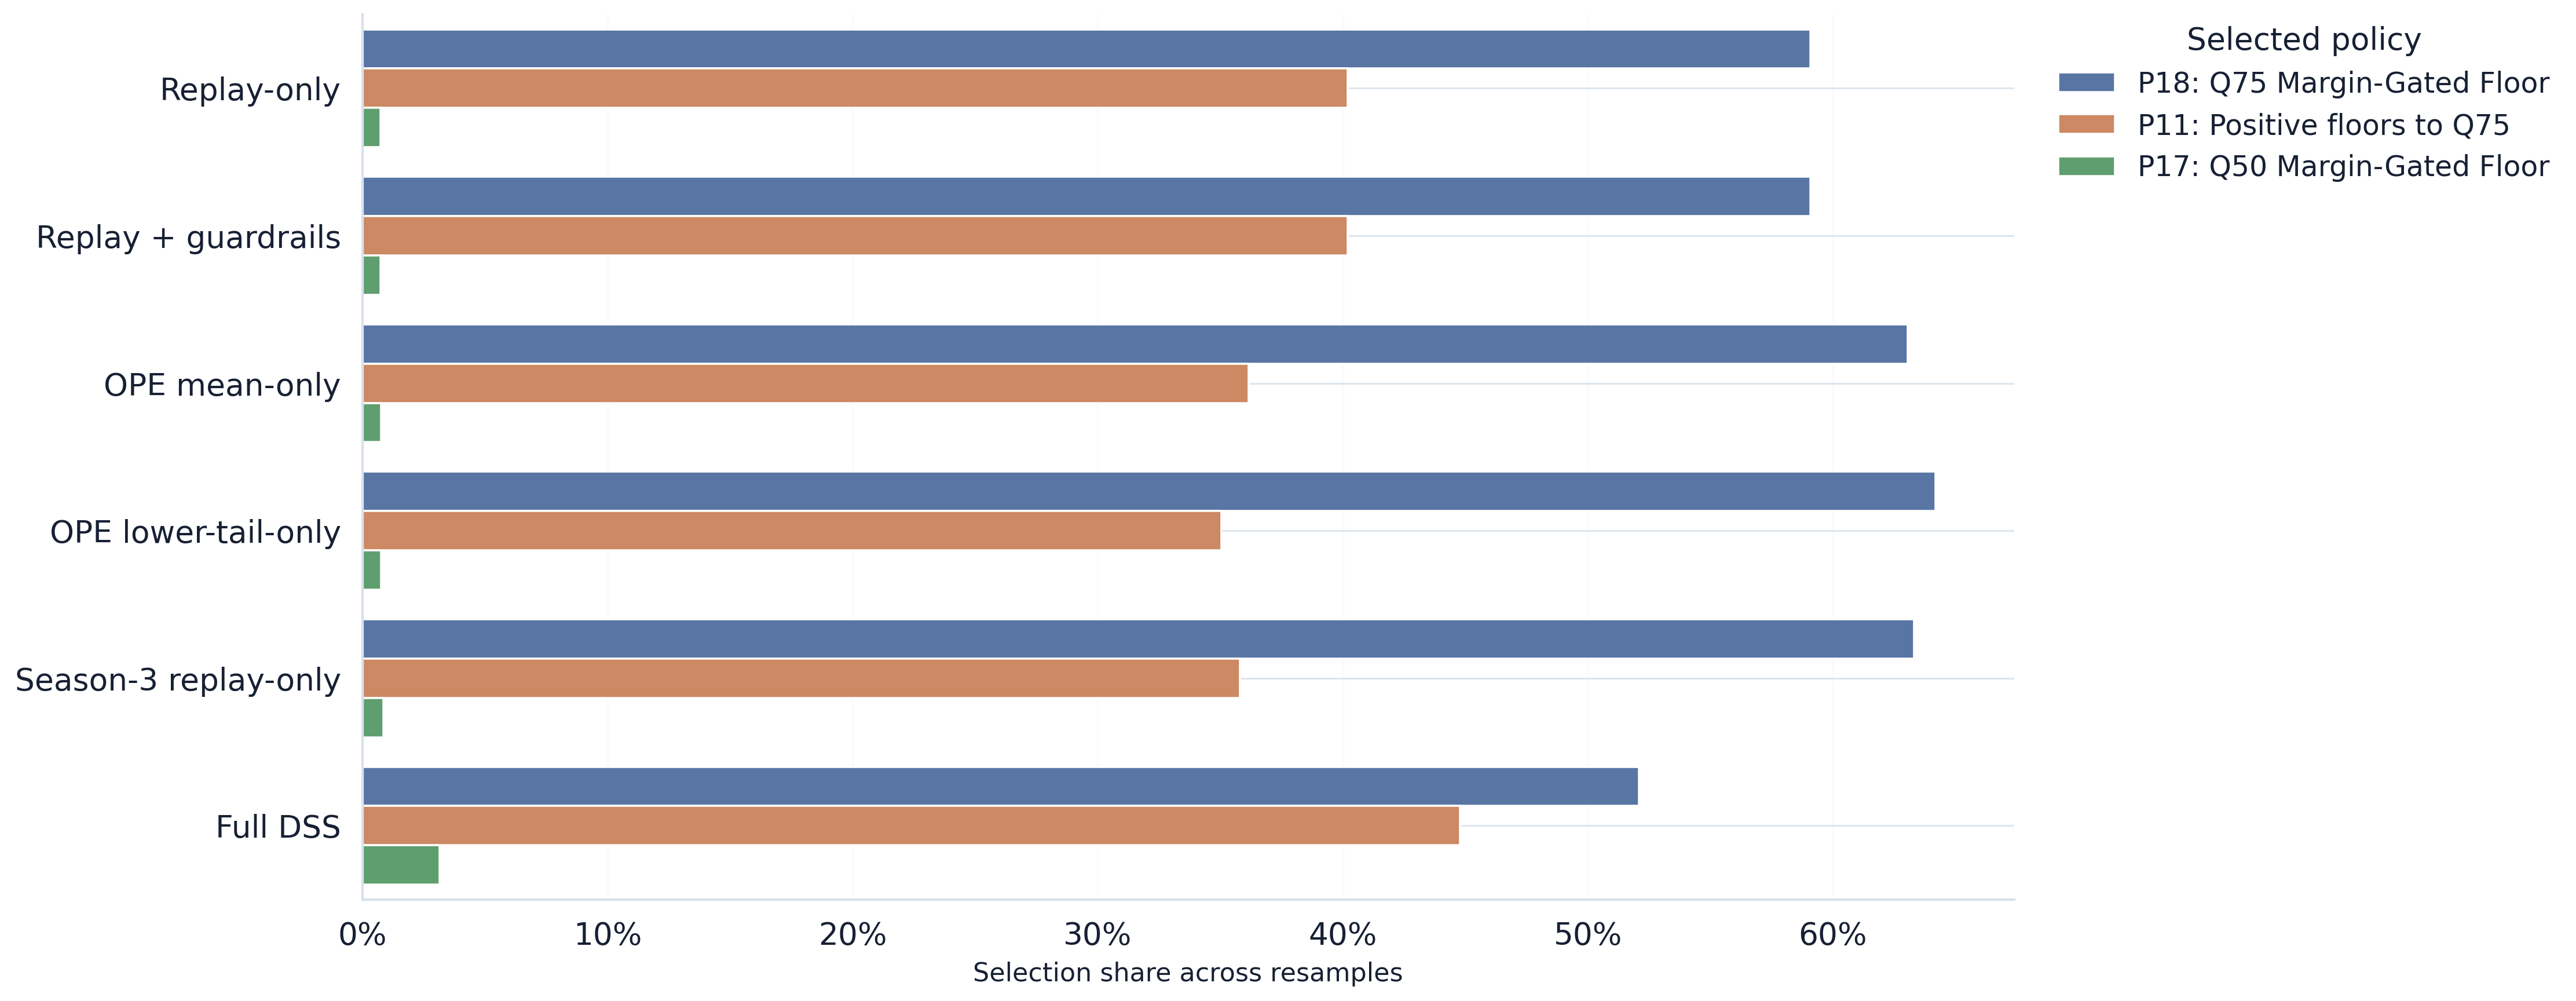

artifacts/figures/14_decision_rule_bootstrap_selection.png


In [9]:
if RENDER_FIGURES:
    selection_path = renderer.plot_decision_rule_bootstrap_selection()
else:
    selection_path = paths.figure_dir / "14_decision_rule_bootstrap_selection.png"

display(Image(filename=str(selection_path)))
print(selection_path.relative_to(REPO_ROOT))


## Interpretation for the Paper

The ablation is the closing empirical check for the DSS contribution. Replay, OPE, and Season 3 validation each contribute useful evidence, but none of the simplified rules by itself distinguishes a promising offline policy from a launch-ready policy. The full DSS preserves the strongest candidate while changing the operational action: the policy is worth validating, not launching directly.

This is the last notebook in the paper-facing sequence. At this point the repository has produced the setup panels, EDA, nuisance diagnostics, replay frontier, guardrails, OPE diagnostics, heterogeneity and risk checks, robustness curves, Season 3 transfer, validation design, and decision-rule ablation.
